## Imports

In [22]:
from datetime import UTC, datetime
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt

## Variables

In [9]:
# check if the gdb paths are correct
SIT_AUTOR_DOSSIER_GDB_PATH = Path(
    r"C:\Users\denis.iglesias\Downloads\SIT_AUTOR_DOSSIER.gdb"
)
CAD_BATIMENT_HORSOL_GDB_PATH = Path(
    r"C:\Users\denis.iglesias\Downloads\CAD_BATIMENT_HORSOL.gdb"
)


In [10]:

# check if the gdb paths are correct
assert SIT_AUTOR_DOSSIER_GDB_PATH.exists(), (
    f"Le chemin {SIT_AUTOR_DOSSIER_GDB_PATH} n'existe pas."
)
assert CAD_BATIMENT_HORSOL_GDB_PATH.exists(), (
    f"Le chemin {CAD_BATIMENT_HORSOL_GDB_PATH} n'existe pas."
)

In [11]:
gdf_autor = gpd.read_file(SIT_AUTOR_DOSSIER_GDB_PATH, layer="SIT_AUTOR_DOSSIER")
gdf_autor = gdf_autor[gdf_autor["DATE_DEPOT"] >= datetime(2000, 1, 1, tzinfo=UTC)]

In [12]:
gdf_autor.head(2)

,ID_DOSSIER,TYPE_DOSSIER,TYPE_OPERATION,NOM_DOSSIER,NO_DOSSIER,NO_COMPLEMENTAIRE,STATUT,DATE_DEPOT,DESCRIPTION,OPERATION,ORIGINE,DATE_MAJ_2,LIEN_SAD,geometry
66585,APA 17102/2,APA,--,Autorisation procédure accélérée,17102,2.0,ACCEPTE,2000-11-14 00:00:00+00:00,(portail et clôture) - élargissement du portai...,Non renseigné (valeur par défaut à l'importati...,SAD,2023-11-28 00:00:00+00:00,https://app2.ge.ch/sadconsult/dossier/APA/17102/2,POINT (2504391.2 1123552.41)
66586,APA 27386/1,APA,REN,Autorisation procédure accélérée,27386,1.0,TERMINE,2006-11-24 00:00:00+00:00,Transformation et climatisation de bureaux aux...,Travaux d'entretien et de rénovation intérieur...,SIT,2023-11-28 00:00:00+00:00,https://app2.ge.ch/sadconsult/dossier/APA/27386/1,POINT (2499976.49 1117880.36)


In [13]:
gdf_batiment_horsol = gpd.read_file(CAD_BATIMENT_HORSOL_GDB_PATH)

In [14]:
gdf_batiment_horsol.drop(
    columns=[
        "NO_COMM",
        "NO_BATIMENT",
        "IDENT",
        "NOMBAT",
        "MUTNUM",
        "PROVENANCE",
        "NO_AUTOR",
        "EGRID_LISTE",
        "EGRID_CENTROIDE",
    ],
    inplace=True,
)

In [15]:
gdf_batiment_horsol.head(3)

,COMMUNE,EGID,DATEDT,DESTINATION,NOMENCLATURE,NOMEN_CLASSE,EPOQUE_CONSTRUCTION,ANNEE_CONSTRUCTION,ANNEE_TRANSFORNATION,NIVEAUX_HORSOL,NIVEAUX_SSOL,HAUTEUR,SURFACE,SHAPE_Length,SHAPE_Area,geometry
0,Veyrier,1031173,2016-09-13 15:06:44+00:00,Habitation un logement,1.1.1,Habitation,Période de 1981 à 1985,NaN,NaN,3.0,NaN,4.48,91,46.294559,90.705299,"MULTIPOLYGON (((2500366.216 1114228.42, 250037..."
1,Veyrier,295073184,2006-01-20 17:30:57+00:00,Autre bât. 20m2 et plus,5.1,Autre bâtiment,Période de 1971 à 1980,NaN,NaN,NaN,NaN,5.84,91,42.235823,90.683050,"MULTIPOLYGON (((2502942.38 1113676.281, 250293..."
2,Veyrier,2749270,1998-12-04 00:00:00+00:00,Habitation un logement,1.1.1,Habitation,Période de 1996 à 2000,NaN,NaN,3.0,NaN,7.99,109,42.157512,109.286539,"MULTIPOLYGON (((2502777.214 1114203.843, 25027..."


In [23]:
# Buffer of 1m on points (CRS must be metric — EPSG:2056 is fine)
gdf_autor_buffered = gdf_autor.copy()
gdf_autor_buffered["geometry"] = gdf_autor.buffer(1)

# Spatial join — keep only points inside polygons
gdf_joined = gpd.sjoin(
    gdf_autor_buffered, gdf_batiment_horsol, how="inner", predicate="intersects"
)

In [30]:
gdf_joined.head(5)

,ID_DOSSIER,TYPE_DOSSIER,TYPE_OPERATION,NOM_DOSSIER,NO_DOSSIER,NO_COMPLEMENTAIRE,STATUT,DATE_DEPOT,DESCRIPTION,OPERATION,...,NOMEN_CLASSE,EPOQUE_CONSTRUCTION,ANNEE_CONSTRUCTION,ANNEE_TRANSFORNATION,NIVEAUX_HORSOL,NIVEAUX_SSOL,HAUTEUR,SURFACE,SHAPE_Length,SHAPE_Area
66586,APA 27386/1,APA,REN,Autorisation procédure accélérée,27386,1.0,TERMINE,2006-11-24 00:00:00+00:00,Transformation et climatisation de bureaux aux...,Travaux d'entretien et de rénovation intérieur...,...,Activité,Période de 1919 à 1945,NaN,NaN,7.0,NaN,24.94,456,90.768257,455.611430
66586,APA 27386/1,APA,REN,Autorisation procédure accélérée,27386,1.0,TERMINE,2006-11-24 00:00:00+00:00,Transformation et climatisation de bureaux aux...,Travaux d'entretien et de rénovation intérieur...,...,Activité,Période de 1919 à 1945,NaN,NaN,NaN,NaN,24.88,226,72.382966,225.870295
66587,DD 102127/1,DD,AFF,Demande définitive,102127,1.0,TERMINE,2008-05-23 00:00:00+00:00,transformation d'une grange en habitation -ins...,"Changement d'affectation important, avec ou sa...",...,Activité,NaN,NaN,NaN,NaN,NaN,9.69,186,56.787150,185.533638
66588,APA 17025/1,APA,PI,Autorisation procédure accélérée,17025,1.0,ARCHIVE,2000-04-05 00:00:00+00:00,véranda,"Construction neuve de peu d'importance, isolée...",...,Habitation,Période de 1971 à 1980,NaN,NaN,2.0,NaN,9.69,104,42.657390,104.234317
66589,M 4991/1,M,--,Démolition,4991,1.0,TERMINE,2001-05-31 00:00:00+00:00,"démolition d'une villa, d'un garage et d'une c...",Non renseigné (valeur par défaut à l'importati...,...,Autre bâtiment,Période de 2001 à 2005,NaN,NaN,NaN,NaN,6.65,33,23.055526,33.203960


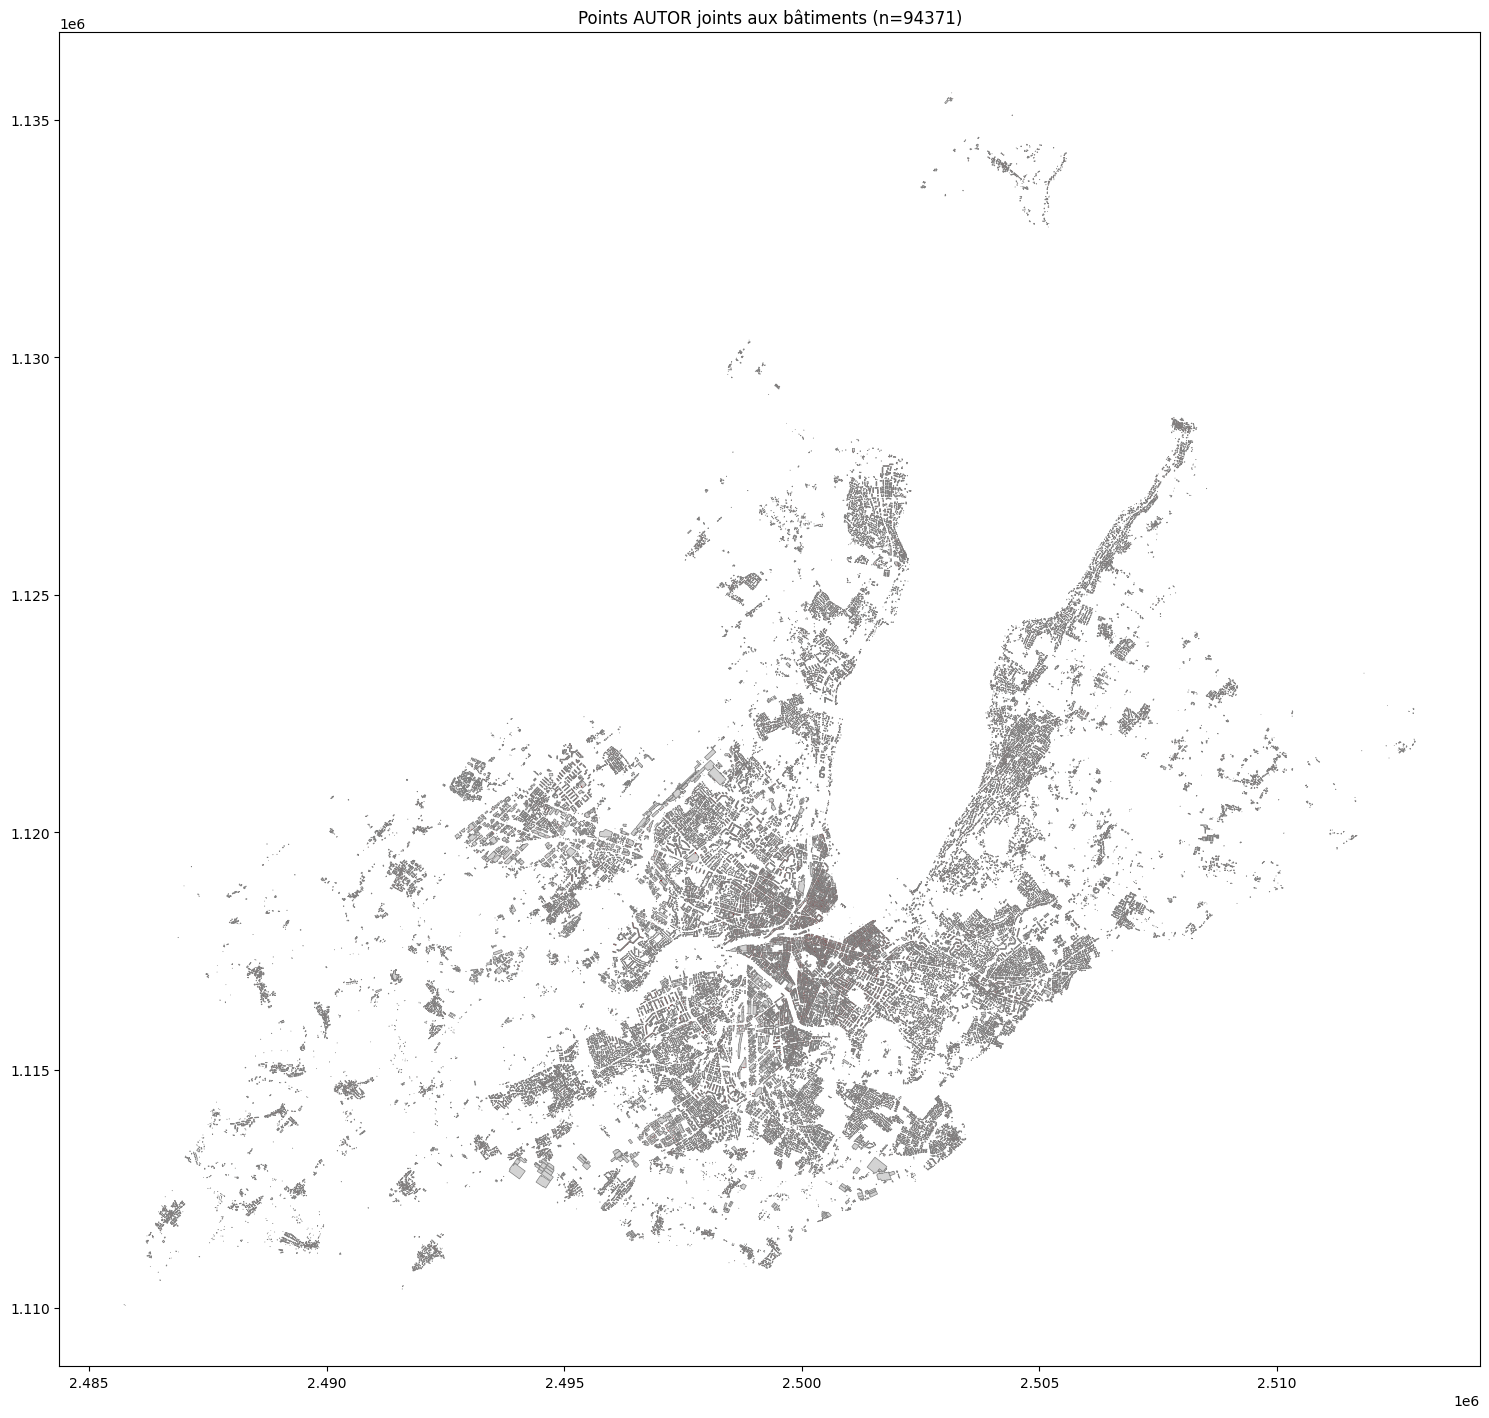

In [25]:

fig, ax = plt.subplots(figsize=(15, 15))

# Bâtiments en fond
gdf_batiment_horsol.plot(ax=ax, color="lightgrey", edgecolor="grey", linewidth=0.5)

# Points joints par-dessus
gdf_joined.plot(ax=ax, color="red", markersize=3)

ax.set_title(f"Points AUTOR joints aux bâtiments (n={len(gdf_joined)})")
plt.tight_layout()
plt.show()